**Consider a random function of the form:**

y = mx + c 

**Import Libraries**

In [8]:
import numpy as np
import random


**Generate Linear Data with Gaussian Noise**

In [9]:
def generate_linear_data(x_values, num_points, slope, intercept, noise_mean, noise_std):

    # Step 1 — Generate random noise from a normal distribution
    noise = np.random.normal(noise_mean, noise_std, num_points)

    # Step 2 — Apply linear equation y = mx + c
    # Then add noise to simulate real-world imperfect data
    y_values = slope * x_values + intercept + noise

    # Step 3 — Return generated y values
    return y_values

**Compute Slope and Intercept (Simple Linear Regression)**

In [10]:

def linear_regression_coefficients(x_vals, y_vals):

    # Step 1 — Calculate mean of x and y
    x_mean = np.mean(x_vals)
    y_mean = np.mean(y_vals)

    # Step 2 — Initialize numerator and denominator
    Total_num = 0
    Total_den = 0

    # Step 3 — Loop through each data point
    for i in range(min(len(x_vals), len(y_vals))):
        
        # Numerator: sum of (yi - y_mean) * xi
        Total_num = Total_num + ((y_vals[i] - y_mean) * x_vals[i])
        
        # Denominator: sum of (xi - x_mean) * xi
        Total_den = Total_den + ((x_vals[i] - x_mean) * x_vals[i])
    
    # Step 4 — Calculate slope
    w1 = Total_num / Total_den

    # Step 4 — Calculate intercept
    w0 = y_mean - (w1 * x_mean)

    return w1, w0
    
    

In [11]:

# Step 1 — Generate random input values
x_inputs = np.random.random(100)

# Step 2 — Generate output data from the true model (no noise)
y = generate_linear_data(x_inputs, 100, 1.5, 3, 0, 0)

# Step 3 — Generate output data with noise
yn = generate_linear_data(x_inputs, 100, 1.5, 3, 0, 0.1)

# Step 4 — Estimate slope and intercept from perfect data
m_est, c_est = linear_regression_coefficients(x_inputs, y)

# Step 5 — Estimate slope and intercept from noisy data
m_est_noise, c_est_noise = linear_regression_coefficients(x_inputs, yn)

# Step 6 — Print estimated parameters
print(round(m_est, 2)) # Estimated slope for perfect data
print(round(c_est, 2)) # Estimated intercept for perfect data

print(round(m_est_noise, 2)) # Estimated slope for noisy data
print(round(c_est_noise, 2)) # Estimated intercept for noisy data


1.5
3.0
1.49
3.01


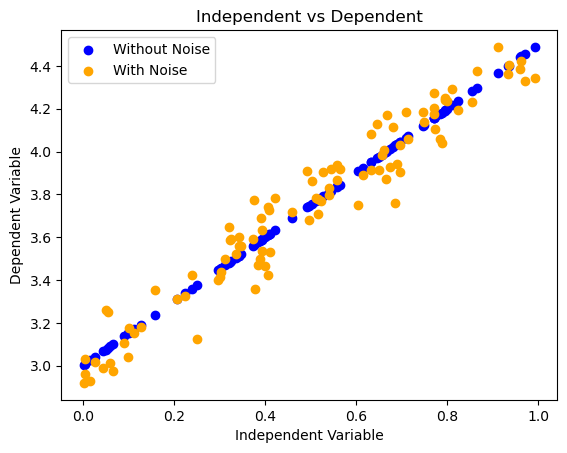

In [12]:
import matplotlib.pyplot as plt
plt.scatter(x_inputs, y, color='blue', label='Without Noise')
plt.scatter(x_inputs, yn, color='orange', label='With Noise')
plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
#plt.yscale(3)
plt.title("Independent vs Dependent")
plt.legend()
plt.show()

In [13]:
noise_levels = [0.1, 1, 3, 5, 10, 15, 20, 25]
m_differ_collect = [] # Actual vs Noisy slopes collection

# Generate x values
xm = np.random.random(10000)

# True model parameters
m = 1.5
c = 3

# Noise settings
num_points = 10000
noise_mean = 0

for noise_std in noise_levels:

    # Generate y values with current noise level
    y_noisy = generate_linear_data(xm, num_points, m, c, noise_mean, noise_std)

    # Generate y values with no noise (perfect line)
    y_perfect = generate_linear_data(xm, num_points, m, c, noise_mean, 0)

    # Estimate slope and intercept from noisy data
    m_est_noisy, c_est_noisy = linear_regression_coefficients(xm, y_noisy)

    # Estimate slope and intercept from perfect data
    m_est_perfect, c_est_perfect = linear_regression_coefficients(xm, y_perfect)

    m_difference = m_est_perfect - m_est_noisy

    m_differ_collect.append(m_difference)

    print("Noise std:", noise_std)
    print("Noisy estimates   ->", round(m_est_noisy, 2), round(c_est_noisy, 2))
    print("Perfect estimates ->", round(m_est_perfect, 2), round(c_est_perfect, 2))
    print("Mp - Mn->", round(m_difference, 2))
    print()

Noise std: 0.1
Noisy estimates   -> 1.5 3.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.0

Noise std: 1
Noisy estimates   -> 1.57 2.97
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.07

Noise std: 3
Noisy estimates   -> 1.45 3.01
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.05

Noise std: 5
Noisy estimates   -> 1.58 2.92
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.08

Noise std: 10
Noisy estimates   -> 1.62 2.95
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.12

Noise std: 15
Noisy estimates   -> 0.65 3.3
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.85

Noise std: 20
Noisy estimates   -> 1.08 3.09
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.42

Noise std: 25
Noisy estimates   -> 2.98 2.75
Perfect estimates -> 1.5 3.0
Mp - Mn-> -1.48



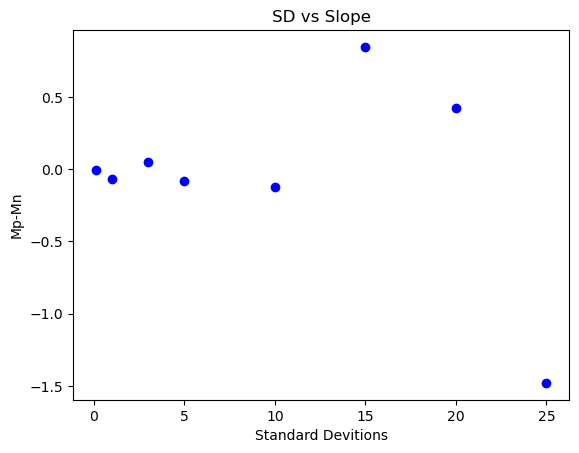

In [14]:

import matplotlib.pyplot as plt
plt.scatter(noise_levels, m_differ_collect, color='blue')
#plt.scatter(, yn, color='orange', label='With Noise')
plt.xlabel("Standard Devitions")
plt.ylabel("Mp-Mn")
#plt.xlim(0.1, 25)
#plt.xscale(log)
plt.title("SD vs Slope")
#plt.legend()
plt.show()